<a href="https://colab.research.google.com/github/winniewyl/super-bowl-ad-analysis/blob/main/notebooks/model_training_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# SECTION 0: Mount Google Drive
# ================================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================================================
# SECTION 1: Load Merged Dataset
# ================================================================
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/super-bowl-ad-analysis/data/clean/merged_ad_data.csv')
print("✅ Loaded dataset with shape:", df.shape)
df.head()

✅ Loaded dataset with shape: (153, 10)


,source_url,brand,year,summary,sentiment,search_term,avg_reddit_sentiment,avg_comment_score,num_comments,success
0,https://youtu.be/KDorKy-13ak?si=kGMUBj7mOvSdjm1Z,State Farm,2024,Arnold Schwarzenegger struggles to deliver Sta...,"Humorous, Playful",State Farm Super Bowl 2024 ad,0.028495,212.419355,31,0
1,https://www.superbowl-ads.com/liquid-death-sup...,Liquid Death,2025,Celebrities and influencers hawk absurd Liquid...,"Humorous, satirical",Liquid Death Super Bowl 2025 ad,0.019078,1076.220000,100,0
2,https://www.superbowl-ads.com/liquid-death-sup...,Liquid Death,2025,Celebrities are shown obsessively licking a Li...,"Humorous, Absurd",Liquid Death Super Bowl 2025 ad,0.019078,1076.220000,100,0
3,https://www.superbowl-ads.com/openai-super-bow...,OpenAI,2025,The commercial depicts various individuals usi...,"Optimistic, empowering",OpenAI Super Bowl 2025 ad,0.129578,274.250000,40,1
4,https://www.superbowl-ads.com/openai-super-bow...,OpenAI,2025,The commercial depicts various everyday scenar...,"Optimistic, Innovative",OpenAI Super Bowl 2025 ad,0.129578,274.250000,40,1


In [ ]:
# ================================================================
# SECTION 2: Train-Test Split
# ================================================================
from sklearn.model_selection import train_test_split

# Select features and target
X = df[['avg_reddit_sentiment', 'avg_comment_score', 'num_comments']]
y = df['success']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Training samples:", X_train.shape[0])
print("✅ Test samples:", X_test.shape[0])

✅ Training samples: 122
✅ Test samples: 31


In [ ]:
# ================================================================
# SECTION 3: Train Decision Tree Model
# ================================================================
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)
print("✅ Model training complete")

✅ Model training complete


In [ ]:
# ================================================================
# SECTION 4: Evaluate Model Performance
# ================================================================
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test)
print("📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📈 Classification Report:\n", classification_report(y_test, y_pred))

📊 Confusion Matrix:
 [[19  0]
 [ 0 12]]

📈 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        12

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



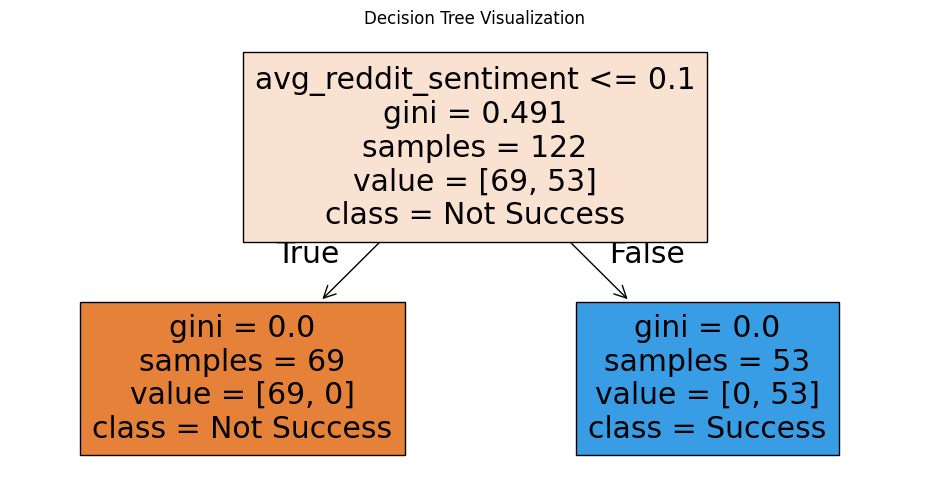

In [ ]:
# ================================================================
# SECTION 5: Visualize Decision Tree
# ================================================================
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=['Not Success', 'Success'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()